In [2]:
import pandas as pd

df = pd.read_csv("../../data/VCT 2025 Pacific Stage 2_csvs/detailed_matches_player_stats.csv")
df.head()

# split score into two numbers
df[["team1_score", "team2_score"]] = df["score_overall"].str.split(" - ", expand=True).astype(int)

# determine winner
df["winner"] = df.apply(
    lambda row: row["team1"] if row["team1_score"] > row["team2_score"] else row["team2"],
    axis=1
)

df["win"] = (df["player_team"] == df["winner"]).astype(int)

df[["team1", "team2", "score_overall", "winner", "player_name", "player_team", "win"]].head(10)


,team1,team2,score_overall,winner,player_name,player_team,win
0,Nongshim RedForce,Team Secret,2 - 1,Nongshim RedForce,Dambi,Nongshim RedForce,1
1,Nongshim RedForce,Team Secret,2 - 1,Nongshim RedForce,Francis,Nongshim RedForce,1
2,Nongshim RedForce,Team Secret,2 - 1,Nongshim RedForce,Rb,Nongshim RedForce,1
3,Nongshim RedForce,Team Secret,2 - 1,Nongshim RedForce,Persia,Nongshim RedForce,1
4,Nongshim RedForce,Team Secret,2 - 1,Nongshim RedForce,Ivy,Nongshim RedForce,1
5,Nongshim RedForce,Team Secret,2 - 1,Nongshim RedForce,n1zzy,Team Secret,0
6,Nongshim RedForce,Team Secret,2 - 1,Nongshim RedForce,kellyS,Team Secret,0
7,Nongshim RedForce,Team Secret,2 - 1,Nongshim RedForce,invy,Team Secret,0
8,Nongshim RedForce,Team Secret,2 - 1,Nongshim RedForce,Wild0reoo,Team Secret,0
9,Nongshim RedForce,Team Secret,2 - 1,Nongshim RedForce,ZesBeeW,Team Secret,0


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

features = ["rating", "acs", "k", "d", "a", "kast", "adr"]

df["kast"] = df["kast"].str.rstrip("%").astype(float)

X = df[features]
y = df["win"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7395833333333334


/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sciki

In [5]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 98  44]
 [ 31 115]]
              precision    recall  f1-score   support

           0       0.76      0.69      0.72       142
           1       0.72      0.79      0.75       146

    accuracy                           0.74       288
   macro avg       0.74      0.74      0.74       288
weighted avg       0.74      0.74      0.74       288



In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))

Decision Tree Accuracy: 0.6319444444444444


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7777777777777778


In [8]:
import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=features)
print(importances.sort_values(ascending=False))

kast      0.217622
rating    0.170542
d         0.150571
acs       0.131685
adr       0.130172
k         0.102186
a         0.097222
dtype: float64


In [ ]:
df["hs_percent"] = df["hs_percent"].astype(str).str.rstrip("%").astype(float)
print(df[candidate_features].dtypes) # type: ignore


rating        float64
acs             int64
k               int64
d               int64
a               int64
kast          float64
adr             int64
kd_diff         int64
hs_percent    float64
fk              int64
fd              int64
fk_fd_diff      int64
dtype: object


In [14]:
import pandas as pd
features_v2 = [
    "rating", "acs", "k", "d", "a", "kast", "adr",
    "kd_diff", "hs_percent", "fk", "fd", "fk_fd_diff"
]

X2 = df[features_v2]
y = df["win"]

from sklearn.model_selection import train_test_split

X2_train, X2_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model_v2 = LogisticRegression()
log_model_v2.fit(X2_train, y_train)

log_pred_v2 = log_model_v2.predict(X2_test)

print("Logistic Regression v2 Accuracy:", accuracy_score(y_test, log_pred_v2))

from sklearn.ensemble import RandomForestClassifier

rf_model_v2 = RandomForestClassifier(random_state=42)
rf_model_v2.fit(X2_train, y_train)

rf_pred_v2 = rf_model_v2.predict(X2_test)

print("Random Forest v2 Accuracy:", accuracy_score(y_test, rf_pred_v2))


importances_v2 = pd.Series(rf_model_v2.feature_importances_, index=features_v2)
print(importances_v2.sort_values(ascending=False))

Logistic Regression v2 Accuracy: 0.75
Random Forest v2 Accuracy: 0.7465277777777778
kast          0.177623
kd_diff       0.133632
rating        0.099259
d             0.093531
acs           0.091800
adr           0.079083
hs_percent    0.066752
a             0.066044
k             0.060166
fk_fd_diff    0.047569
fd            0.042466
fk            0.042076
dtype: float64


/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_streng

## Model Comparison Summary

Baseline feature set:
- Logistic Regression Accuracy: 0.74
- Random Forest Accuracy: 0.78

Expanded feature set:
- Logistic Regression v2 Accuracy: 0.75
- Random Forest v2 Accuracy: 0.75

Observations:
- Random Forest performed best on the baseline feature set.
- Adding more combat-related features slightly improved logistic regression.
- The same expanded feature set reduced random forest performance, suggesting that some added features introduced noise or redundancy.
- KAST, KD difference, and rating appeared to be the most important predictors.

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf_tuned.fit(X_train, y_train)
rf_tuned_pred = rf_tuned.predict(X_test)

print("Tuned Random Forest Accuracy:", accuracy_score(y_test, rf_tuned_pred))

Tuned Random Forest Accuracy: 0.7465277777777778


## Best Model

The best-performing model was the Random Forest trained on the original feature set
(`rating`, `acs`, `k`, `d`, `a`, `kast`, `adr`), which achieved an accuracy of about 0.778.

A tuned random forest and an expanded feature set were also tested, but neither improved performance.
This suggests that the simpler original feature set captured most of the useful signal without adding unnecessary noise.

Matplotlib is building the font cache; this may take a moment.


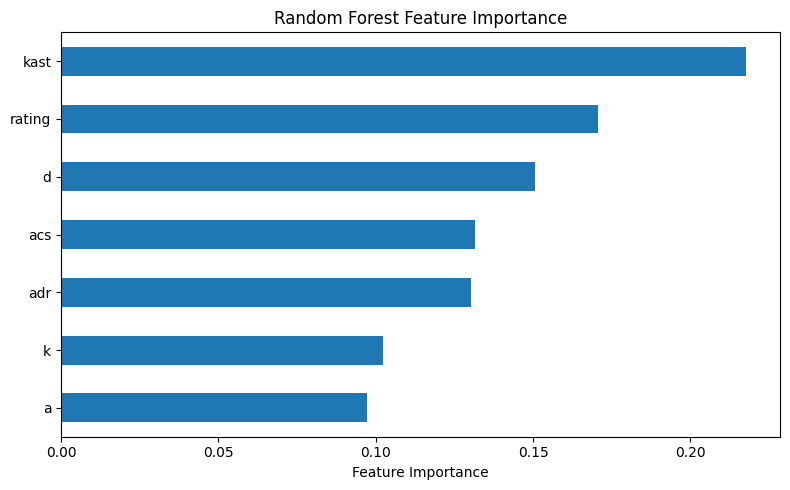

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=features)
importances = importances.sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [17]:
cluster_features = ["rating", "acs", "k", "d", "a", "kast", "adr"]

cluster_df = df[["player_name", "player_team"] + cluster_features].copy()
cluster_df.head()

,player_name,player_team,rating,acs,k,d,a,kast,adr
0,Dambi,Nongshim RedForce,1.29,274,56,40,15,75.0,170
1,Francis,Nongshim RedForce,1.18,246,51,39,24,75.0,161
2,Rb,Nongshim RedForce,1.18,222,46,38,23,75.0,159
3,Persia,Nongshim RedForce,1.02,180,41,38,28,83.0,109
4,Ivy,Nongshim RedForce,0.99,161,37,34,19,77.0,104


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df[cluster_features])

In [23]:
import numpy as np

cluster_df = cluster_df.drop_duplicates(subset=cluster_features)
cluster_df = cluster_df.replace([np.inf, -np.inf], np.nan)
cluster_df = cluster_df.dropna(subset=cluster_features)

In [24]:
scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df[cluster_features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_cluster)

/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sa

In [26]:
print(cluster_df["cluster"].value_counts())

cluster
0    570
1    561
2    299
Name: count, dtype: int64


In [27]:
cluster_summary = cluster_df.groupby("cluster")[cluster_features].mean()
print(cluster_summary)

           rating         acs          k          d          a       kast  \
cluster                                                                     
0        0.734421  152.022807  11.968421  17.142105   5.519298  63.828070   
1        1.242692  239.434938  19.593583  14.529412   6.124777  77.648841   
2        1.004181  198.698997  38.822742  38.501672  15.494983  71.287625   

                adr  
cluster              
0        100.526316  
1        154.465241  
2        129.314381  


In [28]:
cluster_winrate = df[["player_name", "player_team", "rating", "acs", "k", "d", "a", "kast", "adr", "win"]].copy()

cluster_winrate = cluster_winrate.merge(
    cluster_df[["player_name", "player_team", "rating", "acs", "k", "d", "a", "kast", "adr", "cluster"]],
    on=["player_name", "player_team", "rating", "acs", "k", "d", "a", "kast", "adr"],
    how="left"
)

print(cluster_winrate.groupby("cluster")["win"].mean())

cluster
0    0.347826
1    0.650177
2    0.508361
Name: win, dtype: float64


# Valorant Match Outcome Prediction and Performance Clustering

## 1. Project Goal
Predict whether a player's team won based on player match statistics, and group player match performances into playstyle clusters.

## 2. Dataset
VCT 2025 Pacific Stage 2 player-level match statistics.

## 3. Data Preparation
- loaded match-level player data
- created a binary win/loss target from score_overall
- cleaned percentage columns like KAST and headshot rate

## 4. Predictive Modeling
- Logistic Regression
- Decision Tree
- Random Forest

## 5. Clustering Analysis
- standardized selected features
- applied KMeans with 3 clusters
- interpreted performance groups

In [29]:
import pandas as pd

kickoff_df = pd.read_csv("../../data/VCT 2025 Pacific Kickoff_csvs/detailed_matches_player_stats.csv")
stage1_df = pd.read_csv("../../data/VCT 2025 Pacific Stage 1_csvs/detailed_matches_player_stats.csv")
stage2_df = pd.read_csv("../../data/VCT 2025 Pacific Stage 2_csvs/detailed_matches_player_stats.csv")

df_all = pd.concat([kickoff_df, stage1_df, stage2_df], ignore_index=True)

print(df_all.shape)
df_all.head()

(3780, 26)


,match_id,event_name,event_stage,match_date,team1,team2,score_overall,player_name,player_id,player_team,...,a,kd_diff,kast,adr,hs_percent,fk,fd,fk_fd_diff,map_name,map_winner
0,430514,VCT 2025: Pacific Kickoff,Main Event: \n\t\t\t\t\t\tUpper Round 1,2025-01-18 03:00:00,BOOM Esports,T1,1 - 2,Famouz,2348,BOOM Esports,...,11,9,69%,144,15%,13,13,0,NaN,NaN
1,430514,VCT 2025: Pacific Kickoff,Main Event: \n\t\t\t\t\t\tUpper Round 1,2025-01-18 03:00:00,BOOM Esports,T1,1 - 2,BerserX,4874,BOOM Esports,...,10,9,71%,139,27%,7,3,4,NaN,NaN
2,430514,VCT 2025: Pacific Kickoff,Main Event: \n\t\t\t\t\t\tUpper Round 1,2025-01-18 03:00:00,BOOM Esports,T1,1 - 2,dos9,16215,BOOM Esports,...,32,-3,80%,127,30%,3,2,1,NaN,NaN
3,430514,VCT 2025: Pacific Kickoff,Main Event: \n\t\t\t\t\t\tUpper Round 1,2025-01-18 03:00:00,BOOM Esports,T1,1 - 2,Shiro,10739,BOOM Esports,...,29,-6,69%,115,16%,8,7,1,NaN,NaN
4,430514,VCT 2025: Pacific Kickoff,Main Event: \n\t\t\t\t\t\tUpper Round 1,2025-01-18 03:00:00,BOOM Esports,T1,1 - 2,NcSlasher,7043,BOOM Esports,...,26,-15,69%,92,30%,3,5,-2,NaN,NaN


In [30]:
print(kickoff_df.columns.tolist())
print(stage1_df.columns.tolist())
print(stage2_df.columns.tolist())

['match_id', 'event_name', 'event_stage', 'match_date', 'team1', 'team2', 'score_overall', 'player_name', 'player_id', 'player_team', 'stat_type', 'agent', 'rating', 'acs', 'k', 'd', 'a', 'kd_diff', 'kast', 'adr', 'hs_percent', 'fk', 'fd', 'fk_fd_diff', 'map_name', 'map_winner']
['match_id', 'event_name', 'event_stage', 'match_date', 'team1', 'team2', 'score_overall', 'player_name', 'player_id', 'player_team', 'stat_type', 'agent', 'rating', 'acs', 'k', 'd', 'a', 'kd_diff', 'kast', 'adr', 'hs_percent', 'fk', 'fd', 'fk_fd_diff', 'map_name', 'map_winner']
['match_id', 'event_name', 'event_stage', 'match_date', 'team1', 'team2', 'score_overall', 'player_name', 'player_id', 'player_team', 'stat_type', 'agent', 'rating', 'acs', 'k', 'd', 'a', 'kd_diff', 'kast', 'adr', 'hs_percent', 'fk', 'fd', 'fk_fd_diff', 'map_name', 'map_winner']


In [31]:
df_all["kast"] = df_all["kast"].astype(str).str.rstrip("%").astype(float)
df_all["hs_percent"] = pd.to_numeric(
    df_all["hs_percent"].astype(str).str.rstrip("%"),
    errors="coerce"
)

In [32]:
df_all[["team1_score", "team2_score"]] = (
    df_all["score_overall"].str.split(" - ", expand=True).astype(int)
)

df_all["winner"] = df_all.apply(
    lambda row: row["team1"] if row["team1_score"] > row["team2_score"] else row["team2"],
    axis=1
)

df_all["win"] = (df_all["player_team"] == df_all["winner"]).astype(int)

In [33]:
print(df_all["win"].value_counts())
print(df_all.groupby("match_id")["win"].sum().head())

win
0    1890
1    1890
Name: count, dtype: int64
match_id
430514    20
430515    15
430516    20
430517    20
430518    20
Name: win, dtype: int64


In [34]:
features = ["rating", "acs", "k", "d", "a", "kast", "adr"]

X = df_all[features]
y = df_all["win"]

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Combined Data Random Forest Accuracy:", accuracy_score(y_test, y_pred))

Combined Data Random Forest Accuracy: 0.6957671957671958


In [36]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_features = ["rating", "acs", "k", "d", "a", "kast", "adr"]

cluster_df = df_all[["player_name", "player_team"] + cluster_features].copy()
cluster_df = cluster_df.replace([np.inf, -np.inf], np.nan)
cluster_df = cluster_df.dropna(subset=cluster_features)

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df[cluster_features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_cluster)

print(cluster_df["cluster"].value_counts())
print(cluster_df.groupby("cluster")[cluster_features].mean())

cluster
0    1669
1    1396
2     715
Name: count, dtype: int64
           rating         acs          k          d          a       kast  \
cluster                                                                     
0        0.763140  156.363092  12.479329  17.145596   5.783104  65.160575   
1        1.265595  242.710602  20.084527  14.626074   6.472063  78.151862   
2        1.003469  197.983217  42.137063  41.966434  17.469930  71.654545   

                adr  
cluster              
0        103.578191  
1        157.580946  
2        129.579021  


/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/yuto/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sa

In [37]:
cluster_winrate = df_all[["player_name", "player_team", "rating", "acs", "k", "d", "a", "kast", "adr", "win"]].copy()

cluster_winrate = cluster_winrate.merge(
    cluster_df[["player_name", "player_team", "rating", "acs", "k", "d", "a", "kast", "adr", "cluster"]],
    on=["player_name", "player_team", "rating", "acs", "k", "d", "a", "kast", "adr"],
    how="left"
)

print(cluster_winrate.groupby("cluster")["win"].mean())

cluster
0    0.367043
1    0.654558
2    0.509091
Name: win, dtype: float64
